PREPARACIÓN DE LOS DATOS
Cantidad de variables: 8
Cantidad de registros: 17000
Valores nulos: 0

Entrenamiento: (13600, 8)
Prueba: (3400, 8)

ENTRENANDO ÁRBOL: GINI
Accuracy : 0.6738
Precision: 0.6742
Recall   : 0.6738
F1-Score : 0.6739
Profundidad: 29
Hojas: 2832
Nodos: 5663

ENTRENANDO ÁRBOL: ENTROPY
Accuracy : 0.6594
Precision: 0.6598
Recall   : 0.6594
F1-Score : 0.6596
Profundidad: 27
Hojas: 2693
Nodos: 5385

COMPARACIÓN DE ÁRBOLES: GINI VS ENTROPY
  Criterio  Accuracy  Precision  Recall      F1  Profundidad  Hojas  Nodos
0     gini    0.6738     0.6742  0.6738  0.6739           29   2832   5663
1  entropy    0.6594     0.6598  0.6594  0.6596           27   2693   5385

MODELO SELECCIONADO
Criterio: GINI
Profundidad: 29
Número de hojas: 2832
Número de nodos: 5663

RESULTADOS DEL ÁRBOL DE DECISIÓN
Accuracy : 0.6738
Precision: 0.6742
Recall   : 0.6738
F1-Score : 0.6739

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

         Low       0.54      0.54  

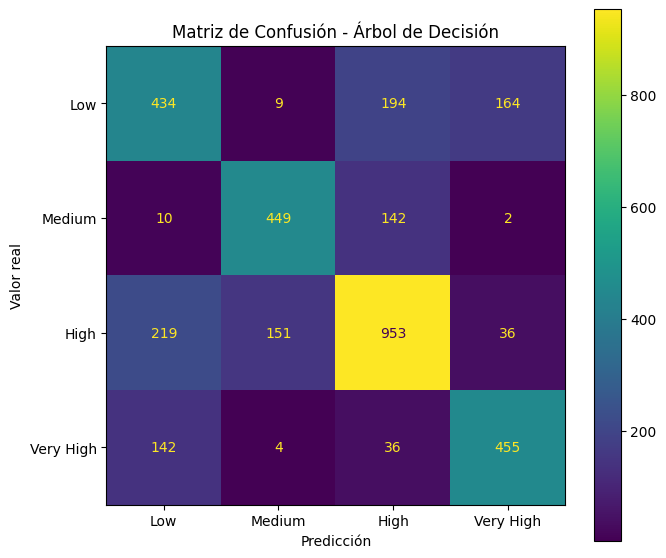

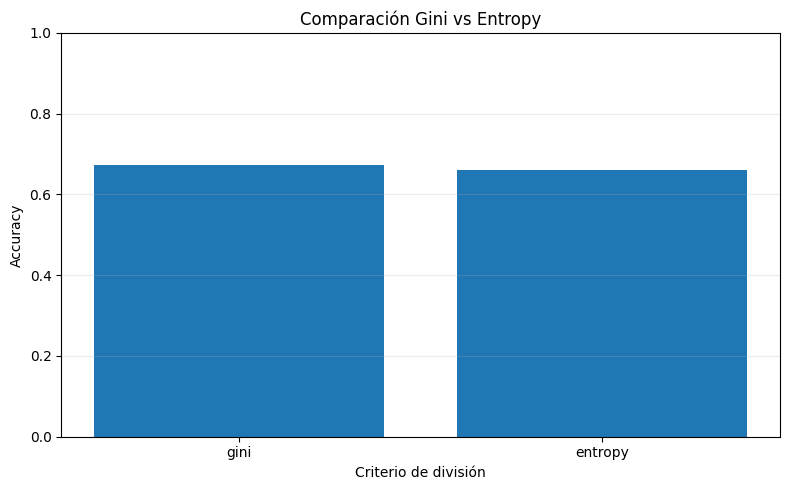


IMPORTANCIA DE LAS VARIABLES
median_income         0.272184
longitude             0.222848
latitude              0.215400
housing_median_age    0.079896
population            0.071402
total_rooms           0.054736
total_bedrooms        0.042321
households            0.041213
dtype: float64


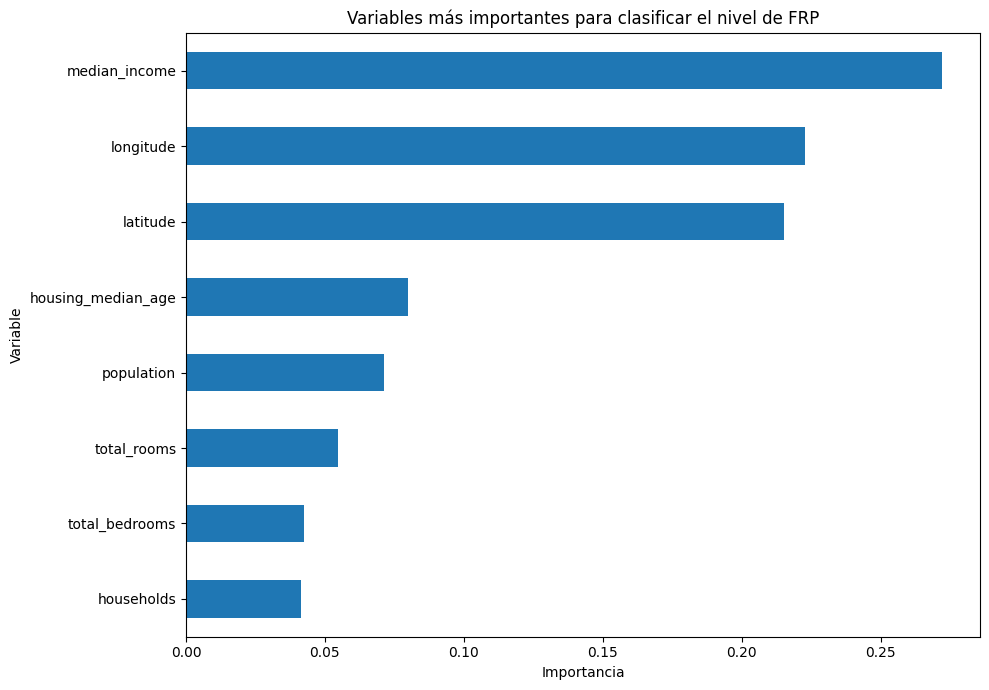

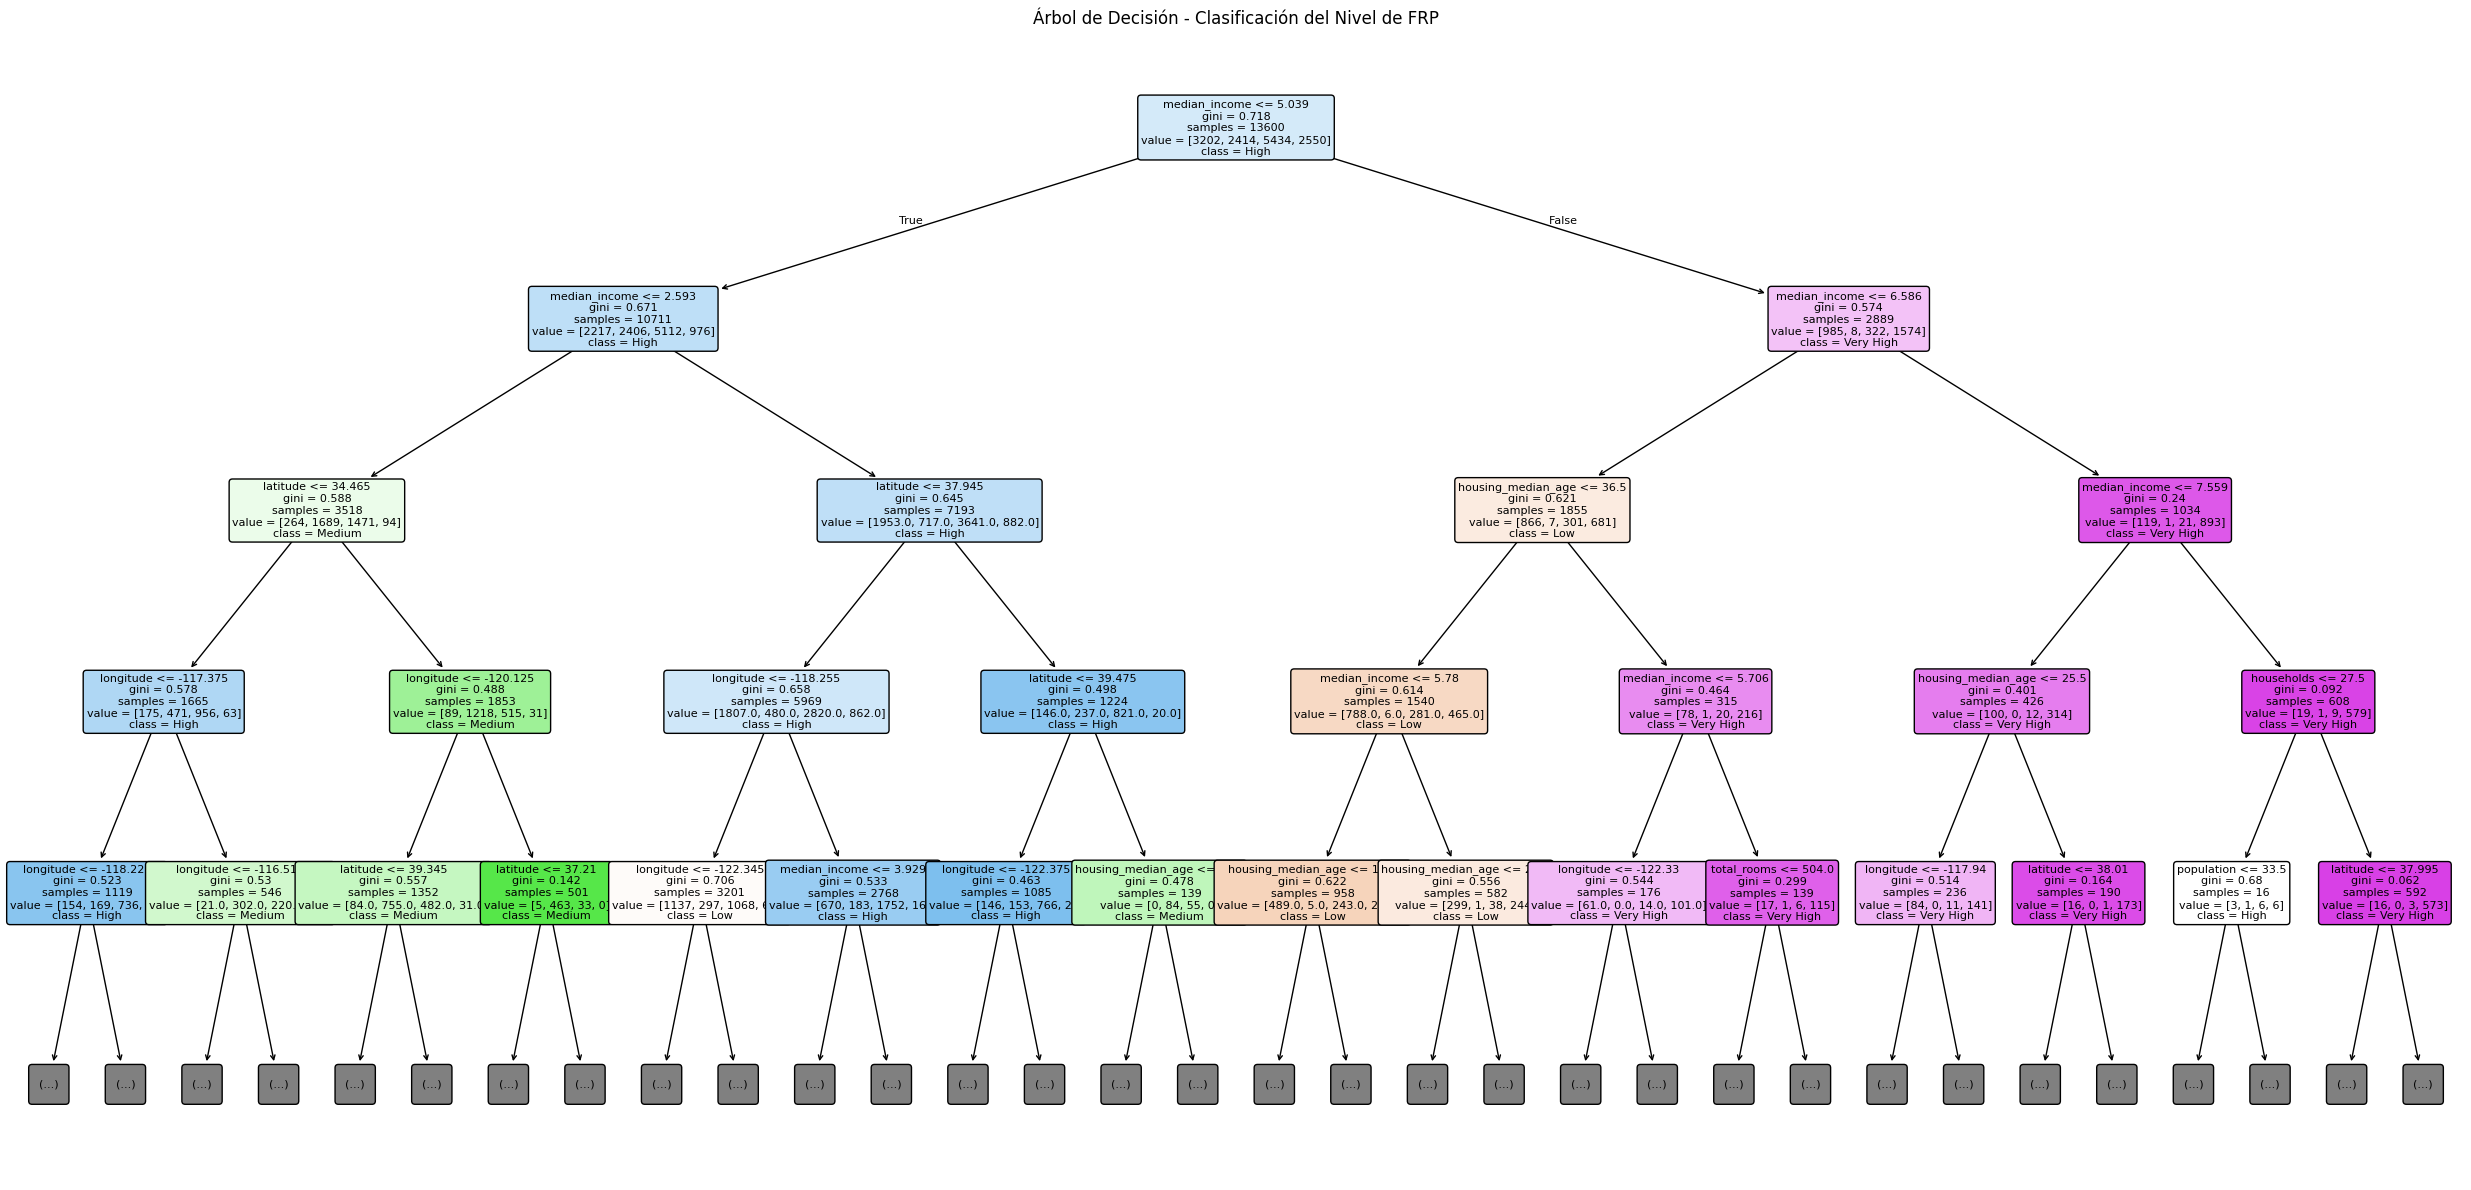


PROBABILIDADES DE PREDICCIÓN
   High  Low  Medium  Very High
0   0.0  0.0     1.0        0.0
1   1.0  0.0     0.0        0.0
2   0.0  0.0     1.0        0.0
3   0.0  0.0     0.0        1.0
4   0.0  0.0     1.0        0.0
5   0.0  0.0     1.0        0.0
6   0.0  0.0     0.0        1.0
7   0.0  0.0     1.0        0.0
8   0.0  0.0     0.0        1.0
9   0.0  1.0     0.0        0.0

PREDICCIONES SOBRE DATOS NO VISTOS
            Real Prediccion
10849     Medium     Medium
14194       High       High
3569        High     Medium
14701  Very High  Very High
2754      Medium     Medium
6044        High     Medium
8142   Very High  Very High
9050      Medium     Medium
7915   Very High  Very High
12799     Medium        Low
9803         Low        Low
6401         Low        Low
16025       High  Very High
8112      Medium     Medium
2928   Very High       High
9879         Low     Medium
12003       High     Medium
7311      Medium       High
6745      Medium     Medium
12197     Medium     M

In [7]:
# ============================================================
# ÁRBOLES DE DECISIÓN
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# FIX: Load the DataFrame 'df'. Replace 'your_data.csv' with your actual data file.
# For example, if you have 'california_housing_train.csv' in your environment:
df = pd.read_csv('/content/sample_data/california_housing_train.csv')
# Or if 'df' is supposed to come from an earlier cell, make sure that cell is run.

# Handle potential NaN values by dropping rows with any missing data
df = df.dropna()


# ============================================================
# 1. VARIABLES PREDICTORAS
# ============================================================

# Adapting to available columns in 'california_housing_train.csv'
X_arbol = df[
    [
        "latitude",
        "longitude",
        "housing_median_age",
        "total_rooms",
        "total_bedrooms",
        "population",
        "households",
        "median_income"
    ]
]


# Variable objetivo - using 'median_house_value' as an example target
y_arbol = df["median_house_value"]

# For classification, we need to convert the continuous target variable to categorical.
# Let's create a simple categorical target based on median_house_value for demonstration.
y_arbol = pd.cut(y_arbol, bins=[0, 100000, 200000, 300000, df['median_house_value'].max()],
                   labels=['Low', 'Medium', 'High', 'Very High'], include_lowest=True)


# ============================================================
# 2. CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ============================================================

# Commenting out this section as the current selected columns do not require it,
# or the original categorical columns are not present in 'california_housing_train.csv'.
# X_arbol = pd.get_dummies(
#     X_arbol,
#     columns=[
#         "daynight",
#         "satellite",
#         "instrument"
#     ],
#     dtype=int
# )


print("=" * 60)
print("PREPARACIÓN DE LOS DATOS")
print("=" * 60)

print("Cantidad de variables:", X_arbol.shape[1])
print("Cantidad de registros:", X_arbol.shape[0])
print("Valores nulos:", X_arbol.isnull().sum().sum()) # Should be 0 after dropna


# ============================================================
# 3. DIVISIÓN DE LOS DATOS
# ============================================================

X_train_arbol, X_test_arbol, y_train_arbol, y_test_arbol = train_test_split(
    X_arbol,
    y_arbol,
    test_size=0.20,
    random_state=42,
    stratify=y_arbol
)


print("\nEntrenamiento:", X_train_arbol.shape)
print("Prueba:", X_test_arbol.shape)


# ============================================================
# 4. COMPARACIÓN GINI VS ENTROPY
# ============================================================

criterios = [
    "gini",
    "entropy"
]


resultados_arbol = []

modelos_arbol = {}


for criterio in criterios:

    print("\n" + "=" * 60)
    print("ENTRENANDO ÁRBOL:", criterio.upper())
    print("=" * 60)

    modelo = DecisionTreeClassifier(
        criterion=criterio,
        random_state=42
    )

    modelo.fit(
        X_train_arbol,
        y_train_arbol
    )


    # Predicciones
    predicciones = modelo.predict(
        X_test_arbol
    )


    # Métricas
    accuracy = accuracy_score(
        y_test_arbol,
        predicciones
    )

    precision = precision_score(
        y_test_arbol,
        predicciones,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_arbol,
        predicciones,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_arbol,
        predicciones,
        average="weighted",
        zero_division=0
    )


    # Guardar resultados
    resultados_arbol.append({

        "Criterio": criterio,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "Profundidad": modelo.get_depth(),

        "Hojas": modelo.get_n_leaves(),

        "Nodos": modelo.tree_.node_count

    })


    modelos_arbol[criterio] = modelo


    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-Score :", round(f1, 4))

    print("Profundidad:", modelo.get_depth())
    print("Hojas:", modelo.get_n_leaves())
    print("Nodos:", modelo.tree_.node_count)


# ============================================================
# 5. TABLA DE COMPARACIÓN
# ============================================================

tabla_arbol = pd.DataFrame(
    resultados_arbol
)


print("\n" + "=" * 70)
print("COMPARACIÓN DE ÁRBOLES: GINI VS ENTROPY")
print("=" * 70)

print(
    tabla_arbol.round(4)
)


# ============================================================
# 6. SELECCIONAR EL MODELO CON MAYOR F1
# ============================================================

mejor_criterio = tabla_arbol.loc[
    tabla_arbol["F1"].idxmax(),
    "Criterio"
]


modelo_arbol = modelos_arbol[
    mejor_criterio
]


y_pred_arbol = modelo_arbol.predict(
    X_test_arbol
)


print("\n" + "=" * 70)
print("MODELO SELECCIONADO")
print("=" * 70)

print("Criterio:", mejor_criterio.upper())
print("Profundidad:", modelo_arbol.get_depth())
print("Número de hojas:", modelo_arbol.get_n_leaves())
print("Número de nodos:", modelo_arbol.tree_.node_count)


# ============================================================
# 7. MÉTRICAS DEL MODELO SELECCIONADO
# ============================================================

accuracy_arbol = accuracy_score(
    y_test_arbol,
    y_pred_arbol
)

precision_arbol = precision_score(
    y_test_arbol,
    y_pred_arbol,
    average="weighted",
    zero_division=0
)

recall_arbol = recall_score(
    y_test_arbol,
    y_pred_arbol,
    average="weighted",
    zero_division=0
)

f1_arbol = f1_score(
    y_test_arbol,
    y_pred_arbol,
    average="weighted",
    zero_division=0
)


print("\n" + "=" * 70)
print("RESULTADOS DEL ÁRBOL DE DECISIÓN")
print("=" * 70)

print("Accuracy :", round(accuracy_arbol, 4))
print("Precision:", round(precision_arbol, 4))
print("Recall   :", round(recall_arbol, 4))
print("F1-Score :", round(f1_arbol, 4))


# ============================================================
# 8. REPORTE DE CLASIFICACIÓN
# ============================================================

print("\n" + "=" * 70)
print("REPORTE DE CLASIFICACIÓN")
print("=" * 70)

print(
    classification_report(
        y_test_arbol,
        y_pred_arbol,
        target_names=y_arbol.cat.categories.tolist(), # Use actual category names
        zero_division=0
    )
)


# ============================================================
# 9. MATRIZ DE CONFUSIÓN
# ============================================================

cm_arbol = confusion_matrix(
    y_test_arbol,
    y_pred_arbol
)


print("\n" + "=" * 70)
print("MATRIZ DE CONFUSIÓN")
print("=" * 70)

print(cm_arbol)


fig, ax = plt.subplots(
    figsize=(7, 6)
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_arbol,
    display_labels=y_arbol.cat.categories.tolist() # Use actual category names
)


disp.plot(
    ax=ax,
    values_format="d"
)


plt.title(
    "Matriz de Confusión - Árbol de Decisión"
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.tight_layout()

plt.show()


# ============================================================
# 10. COMPARACIÓN GINI VS ENTROPY
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    tabla_arbol["Criterio"],
    tabla_arbol["Accuracy"]
)


plt.xlabel("Criterio de división")
plt.ylabel("Accuracy")

plt.title(
    "Comparación Gini vs Entropy"
)


plt.ylim(
    0,
    1
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ============================================================
# 11. IMPORTANCIA DE LAS VARIABLES
# ============================================================

importancias_arbol = pd.Series(
    modelo_arbol.feature_importances_,
    index=X_arbol.columns
).sort_values(
    ascending=False
)


print("\n" + "=" * 70)
print("IMPORTANCIA DE LAS VARIABLES")
print("=" * 70)

print(
    importancias_arbol
)


# Mostrar las 15 variables más importantes

top_importancias = (
    importancias_arbol
    .head(15)
    .sort_values()
)


plt.figure(
    figsize=(10, 7)
)


top_importancias.plot(
    kind="barh"
)


plt.xlabel(
    "Importancia"
)


plt.ylabel(
    "Variable"
)


plt.title(
    "Variables más importantes para clasificar el nivel de FRP"
)


plt.tight_layout()

plt.show()


# ============================================================
# 12. VISUALIZACIÓN DEL ÁRBOL
# ============================================================

plt.figure(
    figsize=(25, 12)
)


plot_tree(
    modelo_arbol,

    feature_names=X_arbol.columns,

    class_names=y_arbol.cat.categories.tolist(), # Use actual category names

    filled=True,

    rounded=True,

    fontsize=8,

    max_depth=4
)


plt.title(
    "Árbol de Decisión - Clasificación del Nivel de FRP"
)


plt.tight_layout()

plt.show()


# ============================================================
# 13. PROBABILIDADES DE PREDICCIÓN
# ============================================================

probabilidades_arbol = modelo_arbol.predict_proba(
    X_test_arbol
)


resultado_probabilidades = pd.DataFrame(
    probabilidades_arbol,
    columns=modelo_arbol.classes_
)


print("\n" + "=" * 70)
print("PROBABILIDADES DE PREDICCIÓN")
print("=" * 70)

print(
    resultado_probabilidades
    .head(10)
    .round(3)
)


# ============================================================
# 14. PREDICCIONES REALES VS PREDICHAS
# ============================================================

resultados_predicciones = X_test_arbol.copy()


resultados_predicciones["Real"] = (
    y_test_arbol.values
)


resultados_predicciones["Prediccion"] = (
    y_pred_arbol
)


print("\n" + "=" * 70)
print("PREDICCIONES SOBRE DATOS NO VISTOS")
print("=" * 70)


print(
    resultados_predicciones[
        ["Real", "Prediccion"]
    ].head(20)
)